## Telco Churn: Modeling and Evaluation

## Data preparation

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
df = pd.read_csv("../projects/telco-churn/data/raw/Telco-Customer-Churn.csv")

In [3]:
# Convert blank TotalCharges values to NaN
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"], errors="coerce"
)

In [4]:
# Separate features and target
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"].map({"No": 0, "Yes": 1})

## Train/test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=123,
    stratify=y,
)

In [6]:
print("Training:", X_train.shape)
print("Test:", X_test.shape)
print("\nTraining churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Training: (5634, 19)
Test: (1409, 19)

Training churn rate: 0.2653532126375577
Test churn rate: 0.2654364797728886


## Preprocessing pipeline

In [7]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
]

In [8]:
# Includes SeniorCitizen because it represents a category despite being 0/1
categorical_features = [
    col for col in X_train.columns
    if col not in numeric_features
]

In [9]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

In [10]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        drop="if_binary",
        handle_unknown="ignore",
    )),
])

In [11]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

## Candidate Models

In [12]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=123,
    )),
])

In [13]:
dummy_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="prior")),
])

In [14]:
random_forest_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=123,
            n_jobs=-1,
        )),
    ])

In [15]:
hist_gradient_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingClassifier(
            random_state=123,
        )),
    ])

## Cross-validated model comparison

In [16]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123,
)

In [17]:
scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
}

In [18]:
models = {
    "Dummy": dummy_pipeline,
    "Logistic regression": logistic_pipeline,
    "Random forest": random_forest_pipeline,
    "Hist gradient boosting": hist_gradient_pipeline
}

In [19]:
for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )
    print(name)
    print(f"PR-AUC:  {scores['test_pr_auc'].mean():.3f}")
    print(f"ROC-AUC: {scores['test_roc_auc'].mean():.3f}")
    print()

Dummy
PR-AUC:  0.265
ROC-AUC: 0.500



Logistic regression
PR-AUC:  0.657
ROC-AUC: 0.846



Random forest
PR-AUC:  0.620
ROC-AUC: 0.828



Hist gradient boosting
PR-AUC:  0.641
ROC-AUC: 0.837



## Hyperparameter tuning

In [20]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"],
}

In [21]:
grid = GridSearchCV(
    logistic_pipeline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
)

In [22]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=123))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verb

In [23]:
print(grid.best_params_)
print(f"Best CV PR-AUC: {grid.best_score_:.3f}")

{'model__C': 10, 'model__class_weight': None}
Best CV PR-AUC: 0.657


Grid search confirms a stable logistic model; default/near-default settings already near-optimal

## Final holdout evaluation

In [24]:
best_model = grid.best_estimator_

In [25]:
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

In [26]:
print(f"Test PR-AUC:  {average_precision_score(y_test, y_proba):.3f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, digits=3))

Test PR-AUC:  0.650
Test ROC-AUC: 0.844

              precision    recall  f1-score   support

           0      0.840     0.894     0.866      1035
           1      0.643     0.529     0.581       374

    accuracy                          0.797      1409
   macro avg      0.742     0.712     0.723      1409
weighted avg      0.788     0.797     0.790      1409



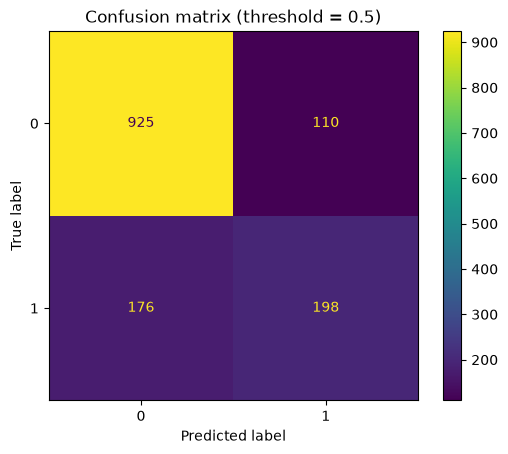

In [27]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion matrix (threshold = 0.5)")
plt.show()

Business interpretation: the model ranks churn risk well, but the default threshold misses nearly half of actual churners. If missed churn is more expensive than an unnecessary retention offer, a lower threshold may be preferable.

Logistic regression generalizes well, achieving test PR-AUC 0.650 and ROC-AUC 0.844. At threshold 0.5 it identifies roughly 53% of churners, so threshold choice should depend on the relative costs of missed churn and unnecessary retention offers.